# Formalizing Majority vs Pareto Principle in Ranking

## 1. Problem Setup

Let:

- $i$: listing  
- $x_i$: listing features (price, location, reviews, etc.)  
- $p_i = P(\text{book} \mid x_i)$: booking probability  
- $v_i$: booking value (≈ price)  

A ranking produces an ordered list:

$$
\pi = (i_1, i_2, ..., i_K)
$$

---

## 2. Majority Principle

The ranking neural network optimizes booking likelihood:

$$
\max_{\pi} \sum_{k=1}^{K} p_{i_k}
$$

### Interpretation

- Maximizes total booking probability  
- Equivalent to:
  - CTR optimization  
  - Booking volume maximization  

### Implication

Empirically:

$$
p_i \downarrow \text{ as price increases}
$$

So the model learns:

- Preference for cheaper listings  
- Rankings dominated by majority behavior  

---

## 3. Pareto Principle (Revenue Concentration)

Define expected booking value:

$$
\text{Value}_i = p_i \cdot v_i
$$

Total objective:

$$
\max_{\pi} \sum_{k=1}^{K} p_{i_k} \cdot v_{i_k}
$$

### Interpretation

- Optimizes revenue instead of volume  
- High-value listings contribute disproportionately  

---

## 4. Source of Conflict

Empirical relationship:

$$
\text{corr}(p_i, v_i) < 0
$$

This implies:

| Objective | Preferred Listings |
|----------|-------------------|
| $\sum p_i$ | Low-price (cheap) |
| $\sum p_i v_i$ | High-price (premium) |

---

## 5. Conflict Hypothesis (H₀)

There does not exist a ranking \( \pi \) that simultaneously maximizes both objectives:

$$
\max_{\pi} \sum_{k=1}^{K} p_{i_k}
\;\;\neq\;\;
\max_{\pi} \sum_{k=1}^{K} p_{i_k} v_{i_k}
$$

### Interpretation

- Majority preference (volume) conflicts with value optimization  
- A single objective cannot represent all users  

---

## 6. Multi-Objective Relaxation

A combined objective:

$$
\max_{\pi} \sum_{k=1}^{K} \left( p_{i_k} + \lambda \cdot p_{i_k} v_{i_k} \right)
$$

Where:

- $\lambda$: trade-off parameter  

### Behavior

- $\lambda = 0$: pure majority optimization  
- $\lambda \rightarrow \infty$: pure revenue optimization  

---

## 7. Diversity as an Implicit Solution

Instead of directly optimizing the combined objective, Airbnb introduces a diversity constraint.

Define:

- \( S \): already selected listings  

Score with similarity penalty:

$$
\text{score}_i = p_i - \lambda \cdot \text{sim}(i, S)
$$

### Effect

- Penalizes redundant (similar) listings  
- Prevents domination by cheap listings  
- Allows high-value outliers into ranking  

---

## 8. Interpretation in System Context

From the system design perspective:

- The base ranker learns **majority preference**  
- The reranker introduces **controlled deviation**  
- Final system balances:
  - relevance (booking probability)
  - diversity (coverage across preferences)

This aligns with:

- Majority Principle → volume optimization  
- Pareto Principle → value concentration  

and explains why:

> optimizing individual items is insufficient — the system must optimize the **entire ranked set** :contentReference[oaicite:0]{index=0}  

---

## 9. Empirical Validation (What to Prove)

To support this formulation:

1. **Negative correlation**
   $$
   \text{corr}(price, bookings) < 0
   $$

2. **Ranking divergence**
   - Top-K by \( p_i \) ≠ Top-K by \( p_i v_i \)

3. **Value concentration**
   - Top ~20% listings contribute disproportionate revenue  

---

## 10. Key Takeaway

The ranking problem is inherently **multi-objective**:

- Optimize for majority → homogeneous, cheap listings  
- Optimize for value → niche, high-priced listings  

Diversity-based reranking acts as a **practical approximation** to resolve this conflict without explicitly solving a multi-objective optimization problem.

In [ ]:
# Task 0: Validate hypothesis (1. Majority vs Paerto conflict, )
# Task 1: Simulate 100k Users with different preferences and behaviors (80/20 split between two user types)  

In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.preprocessing import StandardScaler

In [2]:
DATA_DIR = os.path.join(os.getcwd(), "data")
df_intermediate = pd.read_csv(os.path.join(DATA_DIR, "clean_listings.csv"))

In [3]:
df_intermediate.columns

Index(['accommodates', 'bedrooms', 'beds', 'bathrooms', 'room_type',
       'property_type', 'review_scores_rating', 'review_scores_cleanliness',
       'review_scores_location', 'review_scores_value', 'number_of_reviews',
       'reviews_per_month', 'latitude', 'longitude', 'location', 'price_clean',
       'has_reviews'],
      dtype='str')

In [4]:
df_intermediate.describe(percentiles=[0.25, 0.5, 0.75, 0.85, 0.95, 0.99])

,accommodates,bedrooms,beds,bathrooms,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,number_of_reviews,reviews_per_month,latitude,longitude,price_clean,has_reviews
count,33262.000000,33262.000000,33262.000000,33262.000000,33262.000000,33262.000000,33262.000000,33262.000000,33262.000000,33262.000000,33262.000000,33262.000000,33262.000000,33262.000000
mean,3.515573,1.460375,2.067555,1.323552,4.016081,4.044272,4.085678,3.933809,70.132854,1.720289,42.030281,-12.104133,179.567885,0.855210
std,2.049399,0.917860,1.421034,0.690215,1.699232,1.705146,1.710379,1.672771,116.971916,1.999613,2.651907,36.347406,479.337480,0.351894
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,39.624950,-105.102804,8.000000,0.000000
25%,2.000000,1.000000,1.000000,1.000000,4.400000,4.460000,4.500000,4.270000,3.000000,0.220000,40.408888,-3.708533,84.000000,1.000000
50%,3.000000,1.000000,2.000000,1.000000,4.750000,4.790000,4.840000,4.650000,22.000000,1.040000,40.426270,-3.695745,125.000000,1.000000
75%,4.000000,2.000000,3.000000,1.500000,4.920000,4.940000,4.950000,4.830000,85.000000,2.590000,45.434322,8.547970,186.000000,1.000000
85%,6.000000,2.000000,3.000000,2.000000,4.990000,5.000000,5.000000,4.900000,149.000000,3.610000,45.443430,12.325658,237.000000,1.000000
95%,7.000000,3.000000,5.000000,2.500000,5.000000,5.000000,5.000000,5.000000,312.000000,5.500000,47.370630,12.341209,396.000000,1.000000
99%,10.390000,5.000000,7.000000,4.000000,5.000000,5.000000,5.000000,5.000000,543.000000,8.687800,47.404480,12.360008,911.390000,1.000000


In [5]:
df = df_intermediate.copy()

# ----------------------------
# 1. Normalize components
# ----------------------------
scaler = StandardScaler()

numeric_features = [
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value",
    "number_of_reviews",
    "reviews_per_month",
    "accommodates",
    "bedrooms",
    "bathrooms",
]

X = scaler.fit_transform(df[numeric_features])
X = pd.DataFrame(X, columns=numeric_features)

# ----------------------------
# 2. Construct latent quality
# ----------------------------
# weights chosen to reflect intuition:
# reviews + ratings > size

df["quality"] = (
    0.35 * X["review_scores_rating"] +
    0.15 * X["review_scores_cleanliness"] +
    0.15 * X["review_scores_location"] +
    0.10 * X["review_scores_value"] +
    0.10 * X["number_of_reviews"] +
    0.05 * X["reviews_per_month"] +
    0.05 * X["accommodates"] +
    0.05 * X["bedrooms"]
)

# small noise so it's not deterministic
df["quality"] += np.random.normal(0, 0.1, size=len(df))

In [6]:
df[["price_clean", "quality"]].corr()

,price_clean,quality
price_clean,1.000000,-0.019334
quality,-0.019334,1.000000


<Axes: >

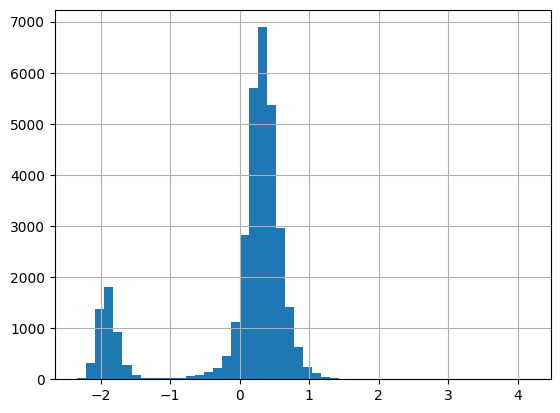

In [7]:
df["quality"].hist(bins=50)

In [8]:
# increase price spread
# df["price"] = lognormal(df['price_clean'] scale=1.5)
df["price"] = df['price_clean']

In [9]:
import numpy as np

# normalize to comparable scale
df["price_norm"] = (df["price"] - df["price"].mean()) / df["price"].std()
df["quality_norm"] = (df["quality"] - df["quality"].mean()) / df["quality"].std()

In [10]:
N_USERS = 100_000

users = []

for _ in range(N_USERS):
    
    if np.random.rand() < 0.8:
        # majority (cheap preference)
        alpha = np.random.normal(0.5, 0.1)   # weak quality weight
        beta  = np.random.normal(1.5, 0.2)   # strong price penalty
        
    else:
        # minority (quality preference)
        alpha = np.random.normal(1.5, 0.2)   # strong quality weight
        beta  = np.random.normal(0.3, 0.1)   # weak price penalty
    
    users.append((alpha, beta))

users = np.array(users)

In [11]:
def compute_utility(df, alpha, beta):
    return alpha * df["quality_norm"] - beta * df["price_norm"]

N_CANDIDATES = 50   # per search

bookings = []
impressions = np.zeros(len(df))

for alpha, beta in users:
    
    # sample candidate set
    candidates = df.sample(N_CANDIDATES)
    
    # compute utility
    utility = compute_utility(candidates, alpha, beta)
    
    # convert to probability (softmax)
    exp_u = np.exp(utility - np.max(utility))
    probs = exp_u / exp_u.sum()
    
    # sample booking
    chosen_idx = np.random.choice(candidates.index, p=probs)
    
    # log
    bookings.append(chosen_idx)
    
    # track impressions
    impressions[candidates.index] += 1

In [12]:
import pandas as pd

df["bookings"] = 0
df.loc[bookings, "bookings"] += 1

df["impressions"] = impressions

# avoid division by zero
df["p_i"] = df["bookings"] / (df["impressions"] + 1e-6)

In [13]:
df

,accommodates,bedrooms,beds,bathrooms,room_type,property_type,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,...,location,price_clean,has_reviews,quality,price,price_norm,quality_norm,bookings,impressions,p_i
0,2,2,2,1.0,Entire home/apt,Entire guesthouse,4.98,4.95,4.98,4.90,...,Denver,139,1,0.639243,139,-0.084633,0.780568,1,166.0,0.006024
1,3,1,1,1.5,Entire home/apt,Entire loft,4.85,4.81,4.65,4.71,...,Denver,213,1,0.213189,213,0.069747,0.260210,1,139.0,0.007194
2,2,1,1,1.0,Private room,Private room in home,4.89,4.61,4.84,4.88,...,Denver,46,1,0.398331,46,-0.278651,0.486332,1,138.0,0.007246
3,1,1,2,1.0,Private room,Private room in home,4.77,4.80,4.87,4.82,...,Denver,40,1,0.586894,40,-0.291168,0.716633,1,154.0,0.006494
4,2,0,1,1.0,Entire home/apt,Entire guesthouse,4.97,4.98,4.89,4.90,...,Denver,87,1,0.392267,87,-0.193116,0.478925,1,152.0,0.006579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33257,8,4,3,2.0,Entire home/apt,Entire rental unit,0.00,0.00,0.00,0.00,...,Zurich,152,0,-1.881483,152,-0.057512,-2.298107,0,150.0,0.000000
33258,1,1,1,1.0,Private room,Private room in rental unit,0.00,0.00,0.00,0.00,...,Zurich,49,0,-2.015637,49,-0.272392,-2.461955,1,170.0,0.005882
33259,1,1,1,1.0,Private room,Private room in rental unit,0.00,0.00,0.00,0.00,...,Zurich,49,0,-1.852761,49,-0.272392,-2.263028,0,147.0,0.000000
33260,6,3,1,1.0,Entire home/apt,Entire rental unit,0.00,0.00,0.00,0.00,...,Zurich,222,0,-1.860543,222,0.088522,-2.272533,0,132.0,0.000000
